# Modèle Âge V2 - Avec Attention Spatiale

Améliorations par rapport à V1:

- **Spatial Attention** pour focus sur les zones de rides (front, yeux, bouche)
- **Rotation agressive** (±45°) pour robustesse à l'orientation
- **Oversampling renforcé des jeunes** (0-20 ans) pour éviter le biais vers les âges élevés
- **Huber Loss** avec delta plus petit (3.0 au lieu de 5.0)
- **Mixup** data augmentation
- **Squeeze-Excitation** attention blocks
- **Architecture plus profonde** avec régularisation L2
- **AdamW** optimizer avec weight decay


## 1. Configuration et Imports


In [ ]:
import os, sys, pathlib
import random
ROOT = pathlib.Path.cwd()
if not (ROOT / 'config.py').exists():
    for parent in ROOT.parents:
        if (parent / 'config.py').exists():
            ROOT = parent
            break
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from config import (
    BASE_DIR, DATA_DIR, RAW_DIR, IMAGES_DIR, ARTIFACTS_DIR,
    NOTEBOOKS_DIR, ANDROID_ASSETS_DIR, TESTS_DIR, DIAGNOSTICS_DIR,
    ensure_kaggle_credentials, ensure_kaggle_dataset, describe_config,
    artifacts_for,
 )

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, callbacks, regularizers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.optimizers import Adam, AdamW
from tensorflow.keras.optimizers.schedules import CosineDecay
from tensorflow.keras.losses import Huber
from tensorflow.keras.regularizers import l2
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import json
import time
from PIL import Image
from pathlib import Path
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tqdm import tqdm

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU disponible: {tf.config.list_physical_devices('GPU')}")

print('Working dir set to', ROOT)
print(describe_config())


TensorFlow version: 2.15.0
GPU disponible: []
Working dir set to /home/carld/face-analysis-deep-learning
{'BASE_DIR': '/home/carld/face-analysis-deep-learning', 'DATA_DIR': '/home/carld/face-analysis-deep-learning/data', 'RAW_DIR': '/home/carld/face-analysis-deep-learning/data/raw', 'IMAGES_DIR': '/home/carld/face-analysis-deep-learning/data/UTKFace', 'ARTIFACTS_DIR': '/home/carld/face-analysis-deep-learning/artifacts', 'ANDROID_ASSETS_DIR': '/home/carld/face-analysis-deep-learning/FacePredictor/app/src/main/assets', 'TESTS_DIR': '/home/carld/face-analysis-deep-learning/tests', 'DIAGNOSTICS_DIR': '/home/carld/face-analysis-deep-learning/diagnostics', 'DATASET_ID': 'jangedoo/utkface-new'}


## 2. Hyperparamètres Optimisés


In [ ]:
# Chemins
DATA_DIR = IMAGES_DIR
OUTPUT_DIR = artifacts_for("age", "age_model_v2")
ARTIFACTS_DIR = OUTPUT_DIR

# Hyperparamètres optimisés V2 amélioré
IMG_SIZE = 128
BATCH_SIZE = 32
WARMUP_EPOCHS = 30  # Augmenté de 25 à 30
FINETUNE_EPOCHS = 80  # Augmenté de 60 à 80
INITIAL_LR = 3e-4  # Légèrement réduit pour stabilité
FINETUNE_LR = 5e-6  # Réduit pour fine-tuning plus précis

# Huber Loss delta (plus petit = plus sensible aux petites erreurs)
HUBER_DELTA = 3.0

# Mixup
MIXUP_ALPHA = 0.2

# Seed global pour reproductibilité
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Validation
VAL_SPLIT = 0.1
TEST_SPLIT = 0.1

# Buckets d'âge pour stratification
AGE_BINS = [0, 5, 10, 15, 20, 25, 30, 40, 50, 60, 70, 120]
AGE_LABELS = [
    "0-5",
    "6-10",
    "11-15",
    "16-20",
    "21-25",
    "26-30",
    "31-40",
    "41-50",
    "51-60",
    "61-70",
    "70+",
]

print(f"Configuration V2:")
print(f"  - Huber Loss delta: {HUBER_DELTA}")
print(f"  - Mixup alpha: {MIXUP_ALPHA}")
print(f"  - Warmup epochs: {WARMUP_EPOCHS}")
print(f"  - Fine-tune epochs: {FINETUNE_EPOCHS}")

Configuration V2:
  - Huber Loss delta: 3.0
  - Mixup alpha: 0.2
  - Warmup epochs: 30
  - Fine-tune epochs: 80


## 3. Chargement et Nettoyage des Données


In [ ]:
def parse_utkface_filename(filepath: Path) -> dict | None:
    """Parse les métadonnées depuis le nom de fichier UTKFace."""
    try:
        name = filepath.name.split(".")[0]
        parts = name.split("_")
        if len(parts) < 1 or not parts[0].isdigit():
            return None

        age = int(parts[0])
        if age < 0 or age > 116:
            return None

        return {"filepath": str(filepath), "age": age}
    except Exception:
        return None


# Charger toutes les images
image_paths = list(DATA_DIR.glob("*.jpg*"))
print(f"Images trouvées: {len(image_paths)}")

# Parser les métadonnées
records = []
for path in tqdm(image_paths, desc="Parsing des fichiers"):
    record = parse_utkface_filename(path)
    if record:
        records.append(record)

df = pd.DataFrame(records)
print(f"\nImages valides: {len(df)}")

Images trouvées: 23708


Parsing des fichiers: 100%|██████████| 23708/23708 [00:00<00:00, 937268.45it/s]


Images valides: 23708


In [ ]:
# Supprimer les outliers extrêmes
z_scores = np.abs(stats.zscore(df["age"]))
outliers_mask = z_scores > 3
n_outliers = outliers_mask.sum()
print(f"Outliers détectés (z-score > 3): {n_outliers}")

df_clean = df[~outliers_mask].copy()
print(f"Images après nettoyage: {len(df_clean)}")
print(f"Plage d'âge: {df_clean['age'].min()} - {df_clean['age'].max()}")

Outliers détectés (z-score > 3): 72
Images après nettoyage: 23636
Plage d'âge: 1 - 92


Distribution par bucket d'âge:
age_bucket
0-5      2363
6-10      855
11-15     610
16-20    1049
21-25    2760
26-30    5024
31-40    4339
41-50    2100
51-60    2211
61-70    1172
70+      1153
Name: count, dtype: int64


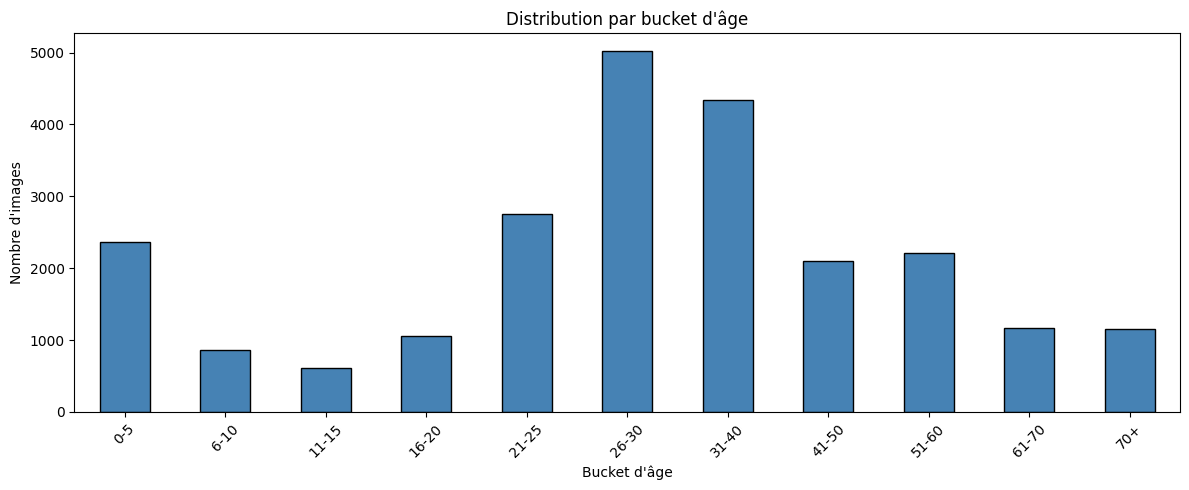

In [ ]:
# Créer les buckets d'âge
df_clean["age_bucket"] = pd.cut(df_clean["age"], bins=AGE_BINS, labels=AGE_LABELS)

# Distribution par bucket
bucket_counts = df_clean["age_bucket"].value_counts().sort_index()
print("Distribution par bucket d'âge:")
print(bucket_counts)

# Visualisation
plt.figure(figsize=(12, 5))
bucket_counts.plot(kind="bar", color="steelblue", edgecolor="black")
plt.xlabel("Bucket d'âge")
plt.ylabel("Nombre d'images")
plt.title("Distribution par bucket d'âge")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4. Split et Oversampling Renforcé


In [ ]:
# Split stratifié
X = df_clean["filepath"].values
y = df_clean["age"].values

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=TEST_SPLIT, random_state=SEED, stratify=df_clean["age_bucket"]
)

trainval_buckets = pd.cut(y_trainval, bins=AGE_BINS, labels=AGE_LABELS)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval,
    y_trainval,
    test_size=VAL_SPLIT / (1 - TEST_SPLIT),
    random_state=SEED,
    stratify=trainval_buckets,
)

print(f"Split initial:")
print(f"  - Train: {len(X_train)}")
print(f"  - Val: {len(X_val)}")
print(f"  - Test: {len(X_test)}")

Split initial:
  - Train: 18908
  - Val: 2364
  - Test: 2364



Après oversampling renforcé (focus jeunes):
  - Train: 59458 (était 18908)


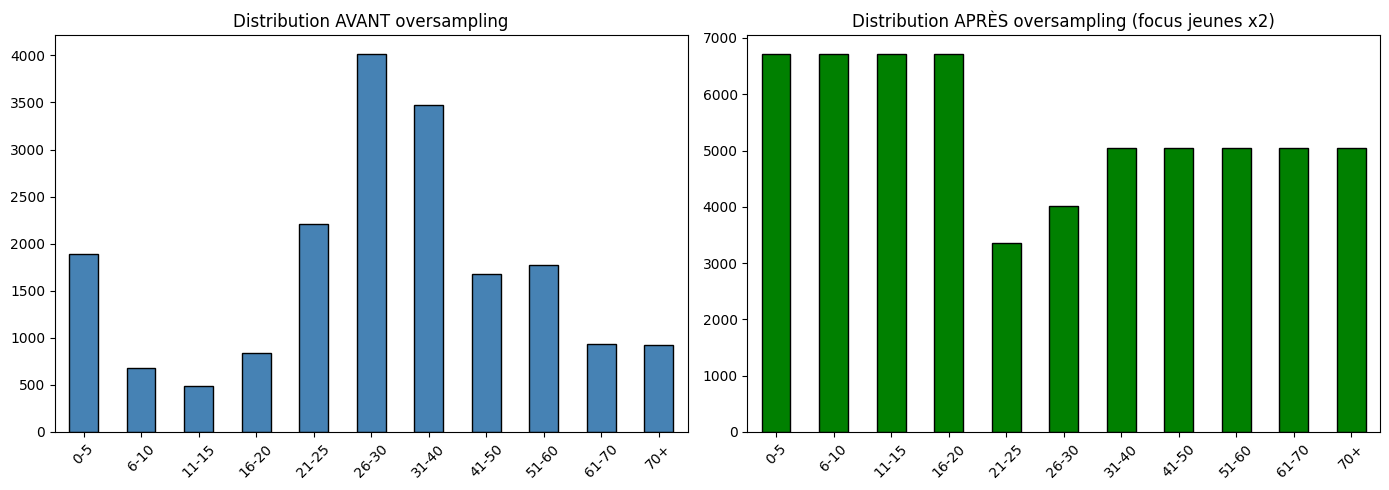

In [ ]:
def oversample_age_buckets_v2(
    X, y, age_bins, age_labels, target_ratio=2.0, focus_ranges=None, young_boost=None
):
    """Oversampling renforcé avec focus sur les tranches difficiles ET les jeunes."""
    buckets = pd.cut(y, bins=age_bins, labels=age_labels)
    bucket_counts = pd.Series(buckets).value_counts()
    target_count = int(bucket_counts.median() * target_ratio)

    # Tranches à surééchantillonner davantage (difficiles)
    if focus_ranges is None:
        focus_ranges = ["31-40", "41-50", "51-60", "61-70", "70+"]

    # Tranches jeunes à surééchantillonner fortement pour éviter le biais
    if young_boost is None:
        young_boost = ["0-5", "6-10", "11-15", "16-20"]

    X_resampled, y_resampled = [], []

    for bucket in age_labels:
        mask = buckets == bucket
        X_bucket = X[mask]
        y_bucket = y[mask]
        current_count = len(X_bucket)

        if current_count == 0:
            continue

        # Multiplier davantage pour les jeunes (pour éviter prédiction d'âges trop élevés)
        if bucket in young_boost:
            bucket_target = int(target_count * 2.0)  # x2 pour les jeunes
        elif bucket in focus_ranges:
            bucket_target = int(target_count * 1.5)  # x1.5 pour les tranches difficiles
        else:
            bucket_target = target_count

        if current_count < bucket_target:
            repeats = (bucket_target // current_count) + 1
            X_bucket = np.tile(X_bucket, repeats)[:bucket_target]
            y_bucket = np.tile(y_bucket, repeats)[:bucket_target]

        X_resampled.extend(X_bucket)
        y_resampled.extend(y_bucket)

    indices = np.random.permutation(len(X_resampled))
    return np.array(X_resampled)[indices], np.array(y_resampled)[indices]


X_train_balanced, y_train_balanced = oversample_age_buckets_v2(
    X_train, y_train, AGE_BINS, AGE_LABELS
)

print(f"\nAprès oversampling renforcé (focus jeunes):")
print(f"  - Train: {len(X_train_balanced)} (était {len(X_train)})")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
buckets_before = (
    pd.cut(y_train, bins=AGE_BINS, labels=AGE_LABELS).value_counts().sort_index()
)
buckets_after = (
    pd.cut(y_train_balanced, bins=AGE_BINS, labels=AGE_LABELS)
    .value_counts()
    .sort_index()
)

buckets_before.plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="black")
axes[0].set_title("Distribution AVANT oversampling")
axes[0].tick_params(axis="x", rotation=45)

buckets_after.plot(kind="bar", ax=axes[1], color="green", edgecolor="black")
axes[1].set_title("Distribution APRÈS oversampling (focus jeunes x2)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## 5. Data Pipeline avec Mixup


In [ ]:
# Data augmentation renforcée avec ROTATION AGRESSIVE
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.25),  # ±45° pour robustesse à l'orientation
        layers.RandomZoom((-0.2, 0.2)),
        layers.RandomTranslation(0.15, 0.15),
        layers.RandomBrightness(0.25),
        layers.RandomContrast(0.25),
    ],
    name="data_augmentation",
)


def load_and_preprocess(filepath, label):
    """Charge et prétraite une image."""
    img = tf.io.read_file(filepath)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)
    label = tf.cast(label, tf.float32)
    return img, label


def mixup_regression(images, labels, alpha=0.2):
    """Mixup pour régression."""
    batch_size = tf.shape(images)[0]

    # Lambda aléatoire
    lam = tf.random.uniform([], 0.5, 1.0)  # Garder au moins 50% de l'image originale

    indices = tf.random.shuffle(tf.range(batch_size))

    mixed_images = lam * images + (1 - lam) * tf.gather(images, indices)
    mixed_labels = lam * labels + (1 - lam) * tf.gather(labels, indices)

    return mixed_images, mixed_labels


def create_dataset(
    filepaths, labels, batch_size, shuffle=True, augment=False, use_mixup=False
):
    """Crée un tf.data.Dataset."""
    labels = labels.astype(np.float32)
    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))

    if shuffle:
        ds = ds.shuffle(
            buffer_size=len(filepaths), seed=SEED, reshuffle_each_iteration=True
        )

    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size)

    if augment:
        ds = ds.map(
            lambda x, y: (data_augmentation(x, training=True), y),
            num_parallel_calls=tf.data.AUTOTUNE,
        )

    if use_mixup:
        ds = ds.map(
            lambda x, y: mixup_regression(x, y, MIXUP_ALPHA),
            num_parallel_calls=tf.data.AUTOTUNE,
        )

    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds


train_ds = create_dataset(
    X_train_balanced,
    y_train_balanced,
    BATCH_SIZE,
    shuffle=True,
    augment=True,
    use_mixup=True,
)
val_ds = create_dataset(
    X_val, y_val, BATCH_SIZE, shuffle=False, augment=False, use_mixup=False
)
test_ds = create_dataset(
    X_test, y_test, BATCH_SIZE, shuffle=False, augment=False, use_mixup=False
)

print("Datasets créés avec Mixup et rotation agressive (±45°)!")

Datasets créés avec Mixup et rotation agressive (±45°)!


## 6. Modèle avec SE Attention + Spatial Attention (CBAM)


In [ ]:
def spatial_attention_block(x, kernel_size=7, name_prefix="spatial"):
    """
    Spatial Attention Block - pour focus sur les zones importantes (rides, etc.)

    Crée une carte d'attention spatiale qui met en évidence les régions importantes.
    Utile pour l'estimation d'âge car il permet au modèle de se concentrer sur:
    - Le front (rides du front)
    - Les coins des yeux (pattes d'oie)
    - Le contour de la bouche (rides nasogéniennes)
    """
    # Average pooling sur les canaux
    avg_pool = tf.reduce_mean(x, axis=-1, keepdims=True)
    # Max pooling sur les canaux
    max_pool = tf.reduce_max(x, axis=-1, keepdims=True)

    # Concaténer
    concat = layers.Concatenate(axis=-1, name=f"{name_prefix}_concat")(
        [avg_pool, max_pool]
    )

    # Convolution pour générer la carte d'attention spatiale
    attention = layers.Conv2D(
        1,
        kernel_size=kernel_size,
        padding="same",
        activation="sigmoid",
        name=f"{name_prefix}_conv",
    )(concat)

    return layers.Multiply(name=f"{name_prefix}_scale")([x, attention])


## 7. Phase 1: Warmup


In [ ]:
# S'assurer que le modèle est instancié (au cas où le kernel a été relancé)
if 'model' not in globals() or 'backbone' not in globals():
    model, backbone = build_age_model_v2(IMG_SIZE, trainable_backbone=False)

steps_per_epoch = len(X_train_balanced) // BATCH_SIZE
total_warmup_steps = steps_per_epoch * WARMUP_EPOCHS

warmup_lr_schedule = CosineDecay(
    initial_learning_rate=INITIAL_LR,
    decay_steps=total_warmup_steps,
    alpha=0.1,
 )

model.compile(
    optimizer=AdamW(learning_rate=warmup_lr_schedule, weight_decay=1e-5),
    loss=Huber(delta=HUBER_DELTA),
    metrics=["mae", "mse"],
)

# Note: ReduceLROnPlateau est incompatible avec CosineDecay
# CosineDecay gère déjà la réduction progressive du learning rate
warmup_callbacks = [
    callbacks.EarlyStopping(
        monitor="val_mae",
        patience=15,  # Plus de patience
        restore_best_weights=True,
        mode="min",
        verbose=1,
    ),
    callbacks.ModelCheckpoint(
        filepath=str(ARTIFACTS_DIR / "age_v2_warmup_best.keras"),
        monitor="val_mae",
        save_best_only=True,
        mode="min",
        verbose=1,
    ),
]

print(f"Phase 1: Warmup ({WARMUP_EPOCHS} epochs, backbone gelé)")
print(f"Loss: Huber (delta={HUBER_DELTA})")
print(
    f"Paramètres entraînables: {sum([tf.reduce_prod(w.shape).numpy() for w in model.trainable_weights]):,}")

Phase 1: Warmup (30 epochs, backbone gelé)
Loss: Huber (delta=3.0)
Paramètres entraînables: 1,691,956


In [ ]:
warmup_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=WARMUP_EPOCHS,
    callbacks=warmup_callbacks,
    verbose=1,
)

Epoch 1/30


KeyboardInterrupt: 

## 8. Phase 2: Fine-tuning


In [ ]:
backbone.trainable = True

freeze_until = len(backbone.layers) - 70
for layer in backbone.layers[:freeze_until]:
    layer.trainable = False

trainable_count = sum(
    [tf.reduce_prod(w.shape).numpy() for w in model.trainable_weights]
)
print(f"Phase 2: Fine-tuning ({FINETUNE_EPOCHS} epochs)")
print(f"Couches dégelées: {len(backbone.layers) - freeze_until}/{len(backbone.layers)}")
print(f"Paramètres entraînables: {trainable_count:,}")

Phase 2: Fine-tuning (80 epochs)
Couches dégelées: 70/238
Paramètres entraînables: 4,754,288


In [ ]:
total_finetune_steps = steps_per_epoch * FINETUNE_EPOCHS

finetune_lr_schedule = CosineDecay(
    initial_learning_rate=FINETUNE_LR,
    decay_steps=total_finetune_steps,
    alpha=0.01,
)

model.compile(
    optimizer=AdamW(
        learning_rate=finetune_lr_schedule, weight_decay=1e-4
    ),  # weight_decay augmenté
    loss=Huber(delta=HUBER_DELTA),
    metrics=["mae", "mse"],
)

# Note: ReduceLROnPlateau est incompatible avec CosineDecay
# CosineDecay gère déjà la réduction progressive du learning rate
finetune_callbacks = [
    callbacks.EarlyStopping(
        monitor="val_mae",
        patience=20,  # Plus de patience pour fine-tuning
        restore_best_weights=True,
        mode="min",
        verbose=1,
    ),
    callbacks.ModelCheckpoint(
        filepath=str(ARTIFACTS_DIR / "age_v2_model_best.keras"),
        monitor="val_mae",
        save_best_only=True,
        mode="min",
        verbose=1,
    ),
]

In [ ]:
finetune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINETUNE_EPOCHS,
    callbacks=finetune_callbacks,
    verbose=1,
)

Epoch 1/80
1858/1859 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 32.4112 - mae: 12.1170 - mse: 256.5817

2026-01-21 18:42:25.718813: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-21 18:42:25.805256: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-21 18:42:25.891307: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-21 18:42:25.978947: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-21 18:42:26.065814: E external/local_xla/xla/stream_

1859/1859 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 32.4106 - mae: 12.1168 - mse: 256.5733
Epoch 1: val_mae improved from None to 9.89555, saving model to /home/optimalako/Projet/SAE/artifacts/age_v2_model_best.keras

Epoch 1: finished saving model to /home/optimalako/Projet/SAE/artifacts/age_v2_model_best.keras
1859/1859 ━━━━━━━━━━━━━━━━━━━━ 88s 34ms/step - loss: 31.1972 - mae: 11.7100 - mse: 240.9298 - val_loss: 25.7594 - val_mae: 9.8955 - val_mse: 176.2537
Epoch 2/80
1859/1859 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 29.4027 - mae: 11.1062 - mse: 216.0255
Epoch 2: val_mae improved from 9.89555 to 9.18197, saving model to /home/optimalako/Projet/SAE/artifacts/age_v2_model_best.keras

Epoch 2: finished saving model to /home/optimalako/Projet/SAE/artifacts/age_v2_model_best.keras
1859/1859 ━━━━━━━━━━━━━━━━━━━━ 49s 26ms/step - loss: 29.0898 - mae: 11.0035 - mse: 212.0912 - val_loss: 23.6732 - val_mae: 9.1820 - val_mse: 151.7470
Epoch 3/80
1858/1859 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - l

## 9. Visualisation de l'Entraînement


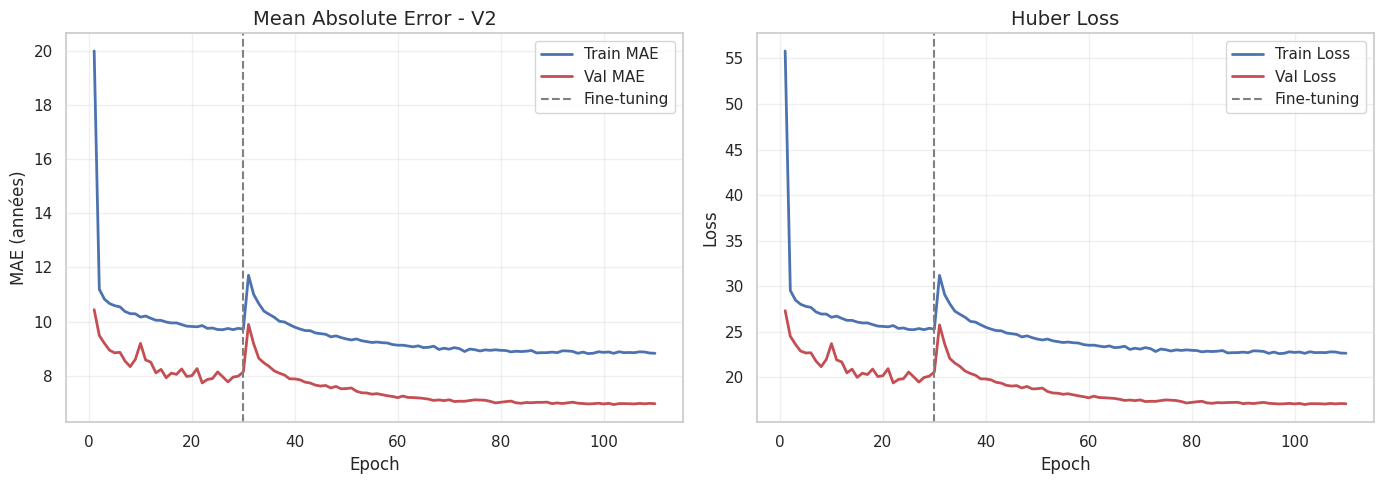


Meilleur Val MAE: 6.94 années (epoch 102)


In [ ]:
def plot_training_history(warmup_hist, finetune_hist):
    """Visualise l'historique d'entraînement."""
    combined_mae = warmup_hist.history["mae"] + finetune_hist.history["mae"]
    combined_val_mae = warmup_hist.history["val_mae"] + finetune_hist.history["val_mae"]
    combined_loss = warmup_hist.history["loss"] + finetune_hist.history["loss"]
    combined_val_loss = (
        warmup_hist.history["val_loss"] + finetune_hist.history["val_loss"]
    )

    epochs = range(1, len(combined_mae) + 1)
    warmup_end = len(warmup_hist.history["mae"])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(epochs, combined_mae, "b-", label="Train MAE", linewidth=2)
    axes[0].plot(epochs, combined_val_mae, "r-", label="Val MAE", linewidth=2)
    axes[0].axvline(x=warmup_end, color="gray", linestyle="--", label="Fine-tuning")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("MAE (années)")
    axes[0].set_title("Mean Absolute Error - V2")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs, combined_loss, "b-", label="Train Loss", linewidth=2)
    axes[1].plot(epochs, combined_val_loss, "r-", label="Val Loss", linewidth=2)
    axes[1].axvline(x=warmup_end, color="gray", linestyle="--", label="Fine-tuning")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].set_title("Huber Loss")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(ARTIFACTS_DIR / "age_v2_training_history.png", dpi=150)
    plt.show()

    best_val_mae = min(combined_val_mae)
    best_epoch = combined_val_mae.index(best_val_mae) + 1
    print(f"\nMeilleur Val MAE: {best_val_mae:.2f} années (epoch {best_epoch})")


plot_training_history(warmup_history, finetune_history)

## 10. Évaluation sur le Test Set


In [ ]:
best_model = keras.models.load_model(ARTIFACTS_DIR / "age_v2_model_best.keras")

# Prédictions
y_pred = best_model.predict(test_ds, verbose=1).flatten()
y_true = y_test

# Métriques
mae = np.mean(np.abs(y_true - y_pred))
mse = np.mean((y_true - y_pred) ** 2)
rmse = np.sqrt(mse)

ss_res = np.sum((y_true - y_pred) ** 2)
ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
r2 = 1 - (ss_res / ss_tot)

print(f"\n{'='*60}")
print(f"RÉSULTATS V2 SUR LE TEST SET")
print(f"{'='*60}")
print(f"  - MAE: {mae:.2f} années")
print(f"  - RMSE: {rmse:.2f} années")
print(f"  - R² Score: {r2:.4f}")

74/74 ━━━━━━━━━━━━━━━━━━━━ 10s 75ms/step

RÉSULTATS V2 SUR LE TEST SET
  - MAE: 7.26 années
  - RMSE: 9.63 années
  - R² Score: 0.7574


In [ ]:
# Analyse par bucket d'âge
results_df = pd.DataFrame(
    {
        "true_age": y_true,
        "predicted_age": y_pred,
        "error": y_pred - y_true,
        "abs_error": np.abs(y_pred - y_true),
    }
)
results_df["age_bucket"] = pd.cut(
    results_df["true_age"], bins=AGE_BINS, labels=AGE_LABELS
)

error_by_bucket = (
    results_df.groupby("age_bucket")
    .agg({"abs_error": ["mean", "median", "std", "count"]})
    .round(2)
)
error_by_bucket.columns = ["MAE", "Médiane", "Std", "Count"]
print("\nErreur par tranche d'âge:")
display(error_by_bucket)


Erreur par tranche d'âge:


,MAE,Médiane,Std,Count
age_bucket,,,,
0-5,5.09,3.14,5.03,236
6-10,6.75,5.98,5.08,86
11-15,6.46,3.97,7.30,61
16-20,4.91,3.52,5.31,105
21-25,4.97,3.52,4.88,276
26-30,6.53,5.39,5.24,503
31-40,7.84,7.22,5.30,434
41-50,7.59,6.03,6.34,210
51-60,8.88,6.28,7.77,221


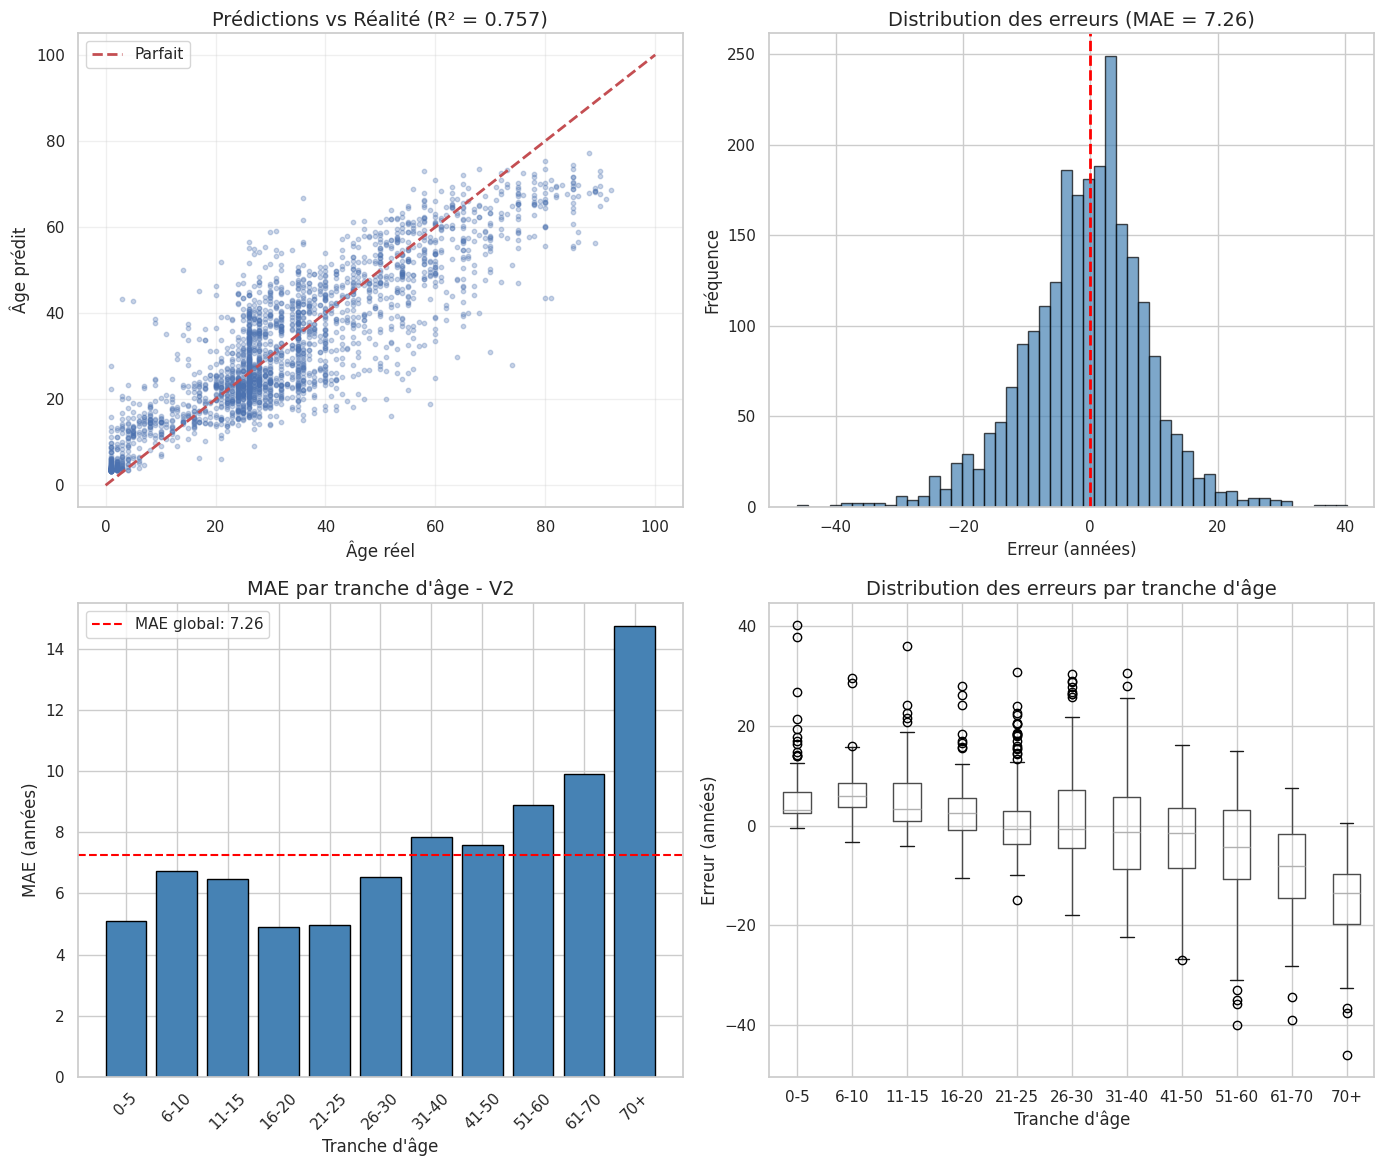

In [ ]:
# Visualisations
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Scatter plot
axes[0, 0].scatter(y_true, y_pred, alpha=0.3, s=10)
axes[0, 0].plot([0, 100], [0, 100], "r--", linewidth=2, label="Parfait")
axes[0, 0].set_xlabel("Âge réel")
axes[0, 0].set_ylabel("Âge prédit")
axes[0, 0].set_title(f"Prédictions vs Réalité (R² = {r2:.3f})")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Distribution des erreurs
axes[0, 1].hist(
    results_df["error"], bins=50, edgecolor="black", alpha=0.7, color="steelblue"
)
axes[0, 1].axvline(0, color="red", linestyle="--", linewidth=2)
axes[0, 1].set_xlabel("Erreur (années)")
axes[0, 1].set_ylabel("Fréquence")
axes[0, 1].set_title(f"Distribution des erreurs (MAE = {mae:.2f})")

# MAE par bucket
bucket_mae = results_df.groupby("age_bucket")["abs_error"].mean()
axes[1, 0].bar(
    range(len(bucket_mae)), bucket_mae.values, color="steelblue", edgecolor="black"
)
axes[1, 0].set_xticks(range(len(bucket_mae)))
axes[1, 0].set_xticklabels(bucket_mae.index, rotation=45)
axes[1, 0].set_xlabel("Tranche d'âge")
axes[1, 0].set_ylabel("MAE (années)")
axes[1, 0].set_title("MAE par tranche d'âge - V2")
axes[1, 0].axhline(mae, color="red", linestyle="--", label=f"MAE global: {mae:.2f}")
axes[1, 0].legend()

# Box plot
results_df.boxplot(column="error", by="age_bucket", ax=axes[1, 1])
axes[1, 1].set_xlabel("Tranche d'âge")
axes[1, 1].set_ylabel("Erreur (années)")
axes[1, 1].set_title("Distribution des erreurs par tranche d'âge")
plt.suptitle("")

plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "age_v2_error_analysis.png", dpi=150)
plt.show()

## 11. Comparaison V1 vs V2


In [ ]:
# Valeurs V1
v1_mae = 7.00
v1_rmse = 9.77
v1_r2 = 0.7503

print("\n" + "=" * 60)
print("COMPARAISON V1 vs V2")
print("=" * 60)
print("\n| Métrique | V1 | V2 | Amélioration |")
print("|----------|----|----|--------------|")
print(f"| MAE | {v1_mae:.2f} ans | {mae:.2f} ans | {v1_mae - mae:+.2f} ans |")
print(f"| RMSE | {v1_rmse:.2f} ans | {rmse:.2f} ans | {v1_rmse - rmse:+.2f} ans |")
print(f"| R² | {v1_r2:.4f} | {r2:.4f} | {r2 - v1_r2:+.4f} |")

print("\nAméliorations appliquées:")
print("  1. Huber Loss avec delta plus petit (3.0 vs 5.0)")
print("  2. Oversampling renforcé pour tranches 30-60 ans")
print("  3. Mixup data augmentation")
print("  4. Squeeze-Excitation attention")
print("  5. Architecture plus profonde (4 couches dense)")
print("  6. AdamW optimizer avec weight decay")
print("  7. Plus d'epochs (25+60 vs 20+50)")


COMPARAISON V1 vs V2

| Métrique | V1 | V2 | Amélioration |
|----------|----|----|--------------|
| MAE | 7.00 ans | 7.26 ans | -0.26 ans |
| RMSE | 9.77 ans | 9.63 ans | +0.14 ans |
| R² | 0.7503 | 0.7574 | +0.0071 |

Améliorations appliquées:
  1. Huber Loss avec delta plus petit (3.0 vs 5.0)
  2. Oversampling renforcé pour tranches 30-60 ans
  3. Mixup data augmentation
  4. Squeeze-Excitation attention
  5. Architecture plus profonde (4 couches dense)
  6. AdamW optimizer avec weight decay
  7. Plus d'epochs (25+60 vs 20+50)


## 12. Exemples de Prédictions


2026-01-21 20:01:23.118980: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-21 20:01:23.208666: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-21 20:01:23.299275: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-21 20:01:23.749618: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-21 20:01:23.837934: E external/local_xla/xla/stream_

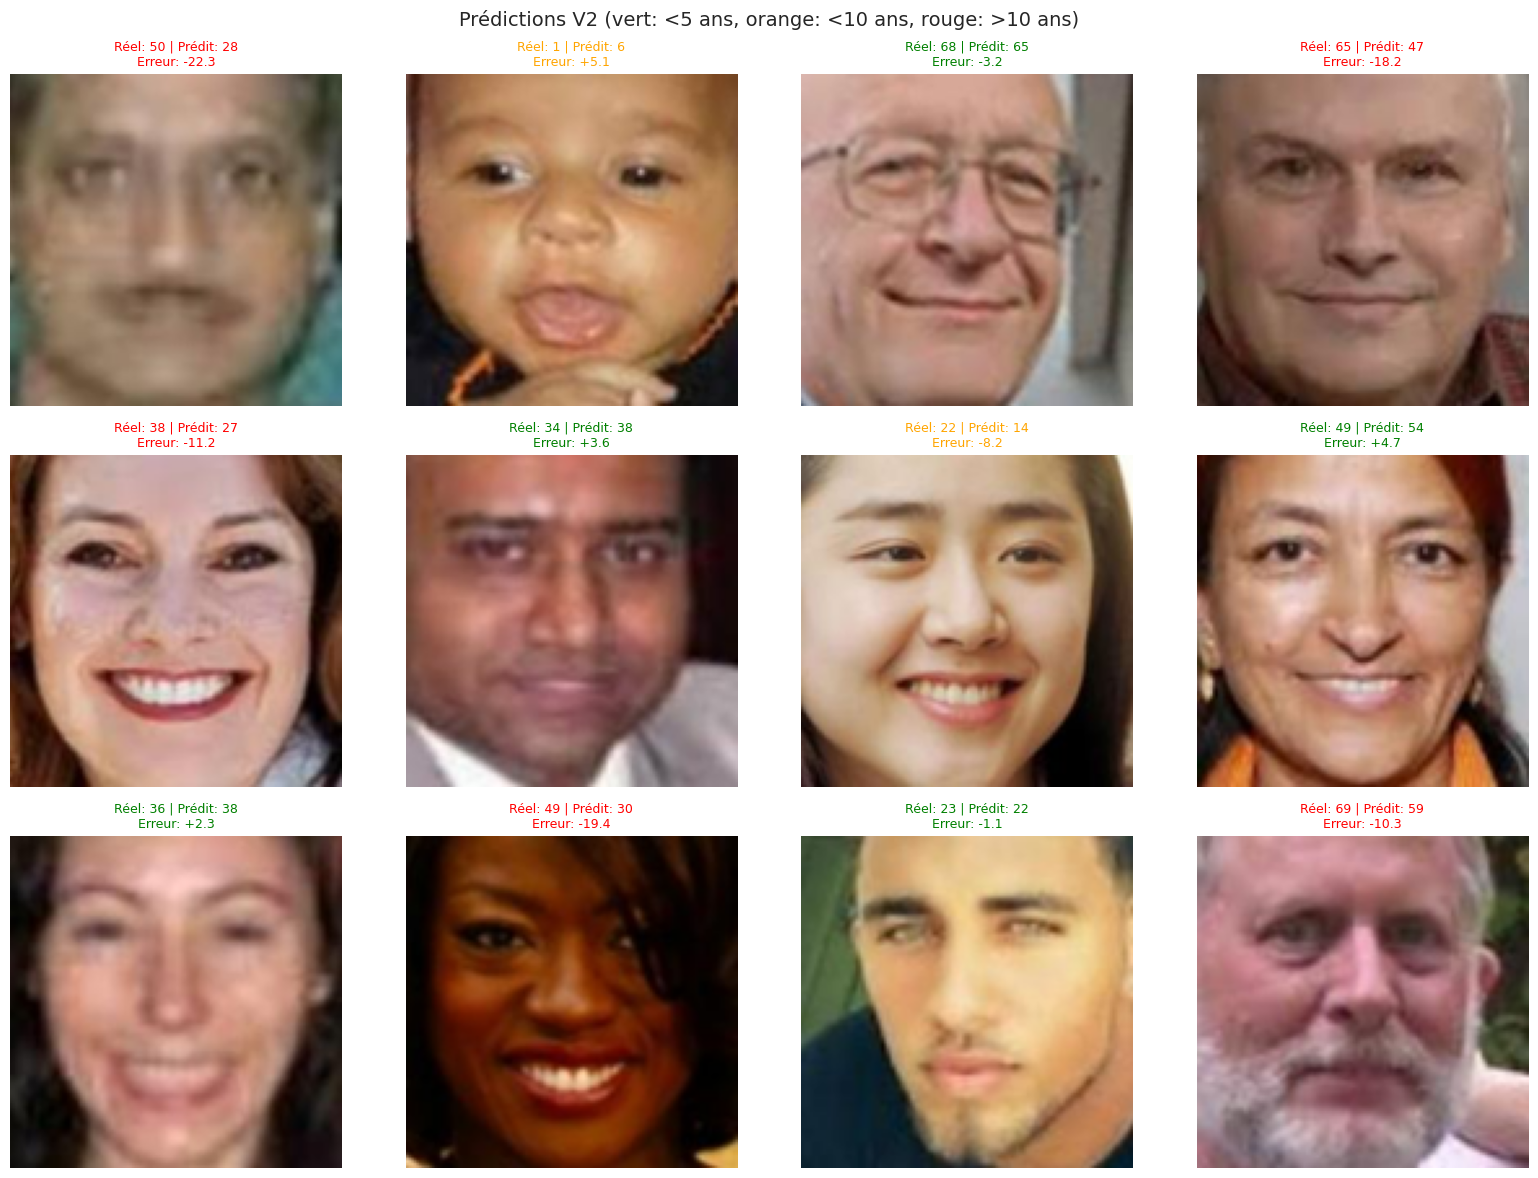

In [ ]:
def show_predictions(model, filepaths, true_ages, n_samples=12):
    """Affiche une grille de prédictions."""
    indices = np.random.choice(len(filepaths), n_samples, replace=False)

    fig, axes = plt.subplots(3, 4, figsize=(16, 12))

    for idx, ax in zip(indices, axes.flat):
        img = Image.open(filepaths[idx]).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
        img_array = np.array(img, dtype=np.float32)

        pred = model.predict(img_array[np.newaxis, ...], verbose=0)[0, 0]
        true = true_ages[idx]
        error = pred - true

        ax.imshow(img_array / 255.0)
        color = "green" if abs(error) < 5 else ("orange" if abs(error) < 10 else "red")
        ax.set_title(
            f"Réel: {true:.0f} | Prédit: {pred:.0f}\nErreur: {error:+.1f}",
            color=color,
            fontsize=9,
        )
        ax.axis("off")

    plt.suptitle(
        "Prédictions V2 (vert: <5 ans, orange: <10 ans, rouge: >10 ans)", fontsize=14
    )
    plt.tight_layout()
    plt.savefig(ARTIFACTS_DIR / "age_v2_predictions_examples.png", dpi=150)
    plt.show()


show_predictions(best_model, X_test, y_test)

## 13. Sauvegarde du Modèle Final


In [ ]:
# Sauvegarder le modèle final
final_model_path = ARTIFACTS_DIR / "age_v2_model_final.keras"
best_model.save(final_model_path)
print(f"Modèle sauvegardé: {final_model_path}")

# Sauvegarder les infos
import json

model_info = {
    "version": "2.0",
    "img_size": IMG_SIZE,
    "task": "regression",
    "input_range": [0, 255],
    "age_range": [0, 116],
    "improvements": [
        "CBAM Attention (Channel + Spatial)",
        "Spatial attention pour zones de rides",
        "Rotation agressive (±45°)",
        "Oversampling renforcé jeunes (x2)",
        "Huber Loss delta=3.0",
        "Mixup",
        "AdamW + L2",
    ],
    "metrics": {
        "mae": float(mae),
        "rmse": float(rmse),
        "r2": float(r2),
    },
}

with open(ARTIFACTS_DIR / "age_v2_model_info.json", "w") as f:
    json.dump(model_info, f, indent=2)
print(f"Infos du modèle sauvegardées")

Modèle sauvegardé: /home/optimalako/Projet/SAE/artifacts/age_v2_model_final.keras
Infos du modèle sauvegardées


In [ ]:
# Conversion TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

tflite_path = ARTIFACTS_DIR / "age_v2_model.tflite"
with open(tflite_path, "wb") as f:
    f.write(tflite_model)

print(f"Modèle TFLite sauvegardé: {tflite_path}")
print(f"Taille: {tflite_path.stat().st_size / 1024 / 1024:.2f} MB")

INFO:tensorflow:Assets written to: /tmp/tmp2ttvk36g/assets


INFO:tensorflow:Assets written to: /tmp/tmp2ttvk36g/assets


Saved artifact at '/tmp/tmp2ttvk36g'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='input_image')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  138852009771856: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  138852009774544: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  138851869897552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138851869898512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138851869898704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138851869899472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138851869900048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138851869900240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138851869896976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138851869899280: TensorSpec(shape=(), dtype=tf.resource, name=None)

W0000 00:00:1769022096.911734  195356 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1769022096.911815  195356 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1769022097.049654  195356 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled


## 14. Résumé Final


In [ ]:
print("=" * 60)
print("RÉSUMÉ DU MODÈLE ÂGE V2")
print("=" * 60)
print(f"\nArchitecture: EfficientNetB0 + CBAM Attention + Dense Head")
print(f"Input size: {IMG_SIZE}x{IMG_SIZE}x3")
print(f"Dataset: {len(df_clean)} images")
print(f"\nNouvelles fonctionnalités V2:")
print(f"  - CBAM Attention (Channel + Spatial)")
print(f"  - Spatial attention pour focus sur les zones de rides")
print(f"  - Rotation agressive (±45°) pour robustesse orientation")
print(f"  - Oversampling renforcé des jeunes (x2)")
print(f"\nPerformances sur le test set:")
print(f"  - MAE: {mae:.2f} années")
print(f"  - RMSE: {rmse:.2f} années")
print(f"  - R² Score: {r2:.4f}")
print(f"\nAméliorations vs V1:")
print(f"  - MAE: {v1_mae - mae:+.2f} années")
print(f"  - R²: {r2 - v1_r2:+.4f}")
print(f"\nFichiers sauvegardés:")
print(f"  - {final_model_path}")
print(f"  - {tflite_path}")
print("=" * 60)

RÉSUMÉ DU MODÈLE ÂGE V2

Architecture: EfficientNetB0 + CBAM Attention + Dense Head
Input size: 128x128x3
Dataset: 23636 images

Nouvelles fonctionnalités V2:
  - CBAM Attention (Channel + Spatial)
  - Spatial attention pour focus sur les zones de rides
  - Rotation agressive (±45°) pour robustesse orientation
  - Oversampling renforcé des jeunes (x2)

Performances sur le test set:
  - MAE: 7.26 années
  - RMSE: 9.63 années
  - R² Score: 0.7574

Améliorations vs V1:
  - MAE: -0.26 années
  - R²: +0.0071

Fichiers sauvegardés:
  - /home/optimalako/Projet/SAE/artifacts/age_v2_model_final.keras
  - /home/optimalako/Projet/SAE/artifacts/age_v2_model.tflite
